# DSCI 552 HW2 - Combined Cycle Power Plant

Goal: predict the net hourly electrical output (PE) of the plant using the 4 ambient variables:
temperature (AT), exhaust vacuum (V), ambient pressure (AP) and relative humidity (RH).

Data is from UCI: https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant

The xlsx file has 5 sheets which are just the same 9568 rows shuffled differently. For parts (b) to (j) I'm only using Sheet1.
At the end I added a small extra part that uses all 5 sheets for the 5x2 CV test mentioned in the dataset readme.

In [1]:
import os
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error as mse

sns.set_style('whitegrid')
pd.set_option('display.precision', 4)
os.makedirs('figures', exist_ok=True)

feats = ['AT', 'V', 'AP', 'RH']

## (a) Load data

In [2]:
df = pd.read_excel('Folds5x2_pp.xlsx', sheet_name='Sheet1')
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## (b) Exploring the data

### i. rows and columns

In [3]:
df.shape

(9568, 5)

9568 rows and 5 columns. Each row is one hour of the plant running at full load.

| column | what it is | unit |
|---|---|---|
| AT | ambient temperature | °C |
| V  | exhaust vacuum | cm Hg |
| AP | ambient pressure | mbar |
| RH | relative humidity | % |
| PE | net hourly electrical output (this is what we predict) | MW |

### ii. pairwise scatterplots

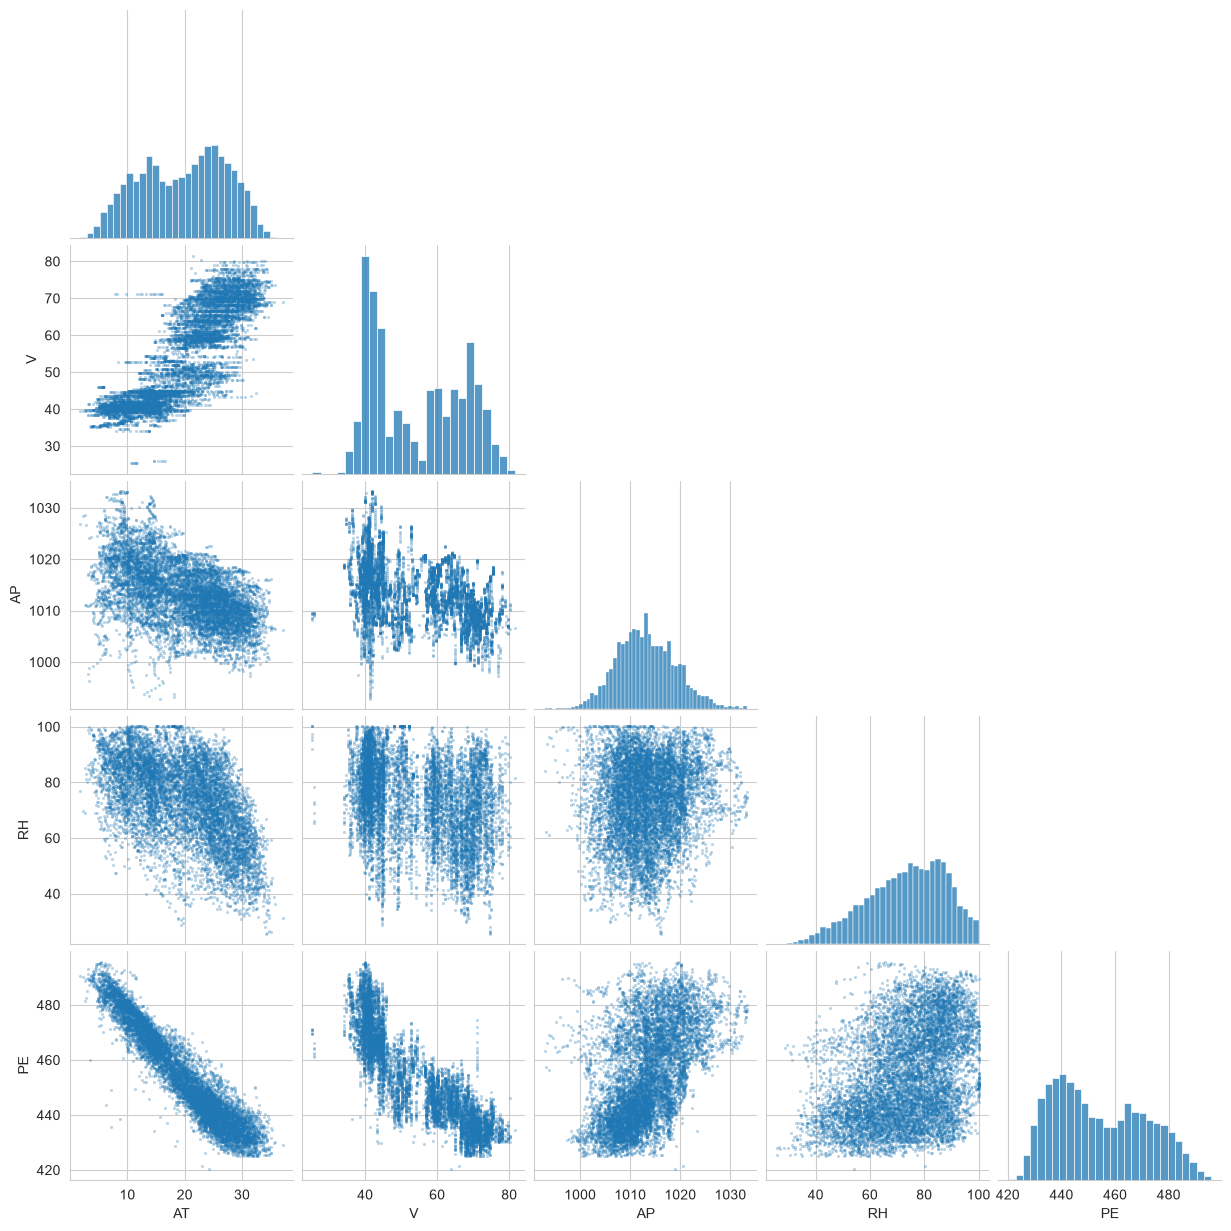

In [4]:
# tiny translucent points, otherwise 9.5k rows is just a blob
g = sns.pairplot(df, corner=True, plot_kws={'s': 4, 'alpha': 0.3, 'edgecolor': None})
g.savefig('figures/pairplot.png', dpi=110)
plt.show()

In [5]:
df.corr().round(3)

,AT,V,AP,RH,PE
AT,1.000,0.844,-0.508,-0.543,-0.948
V,0.844,1.000,-0.414,-0.312,-0.870
AP,-0.508,-0.414,1.000,0.100,0.518
RH,-0.543,-0.312,0.100,1.000,0.390
PE,-0.948,-0.870,0.518,0.390,1.000


Observations:

- AT vs PE is almost a straight line going down (r = -0.95). Makes sense, hot air is less dense so the gas turbine produces less power.
- V vs PE is also strongly negative (r = -0.87) but more spread out.
- AP and RH have a weak positive relation with PE, lots of scatter.
- AT and V are correlated with each other too (r = 0.84). This will matter later in the multiple regression.

### iii. summary statistics

In [6]:
s = df.describe().T
s['median'] = df.median()
s['range'] = s['max'] - s['min']
s['IQR'] = s['75%'] - s['25%']
s[['mean', 'median', 'min', 'max', 'range', '25%', '75%', 'IQR']]

,mean,median,min,max,range,25%,75%,IQR
AT,19.6512,20.345,1.81,37.11,35.30,13.5100,25.72,12.2100
V,54.3058,52.080,25.36,81.56,56.20,41.7400,66.54,24.8000
AP,1013.2591,1012.940,992.89,1033.30,40.41,1009.1000,1017.26,8.1600
RH,73.3090,74.975,25.56,100.16,74.60,63.3275,84.83,21.5025
PE,454.3650,451.550,420.26,495.76,75.50,439.7500,468.43,28.6800


## (c) Simple linear regression for each predictor

Fitting PE ~ X for each of the 4 predictors separately. For outliers I'm using studentized residuals
and counting anything with |r| > 3 as an outlier.

In [7]:
fits, rows = {}, []
for x in feats:
    # fit PE on just one predictor at a time
    m = smf.ols(f'PE ~ {x}', data=df).fit()
    # studentized residuals = residuals scaled so they're roughly N(0,1)
    # so anything with |r| > 3 counts as an outlier
    r = m.get_influence().resid_studentized_external
    # save the model + residuals so the plot cell can reuse them
    fits[x] = (m, r)
    # last column counts how many points are outliers
    rows.append([x, m.params['Intercept'], m.params[x], m.tvalues[x], m.pvalues[x], m.rsquared, (abs(r) > 3).sum()])

pd.DataFrame(rows, columns=['x', 'b0', 'b1', 't', 'p', 'R2', 'outliers']).set_index('x')

,b0,b1,t,p,R2,outliers
x,,,,,,
AT,497.0341,-2.1713,-291.7152,0.0,0.8989,42
V,517.8015,-1.1681,-172.4015,0.0,0.7565,33
AP,-1055.2610,1.4899,59.2962,0.0,0.2688,30
RH,420.9618,0.4557,41.3987,0.0,0.1519,2


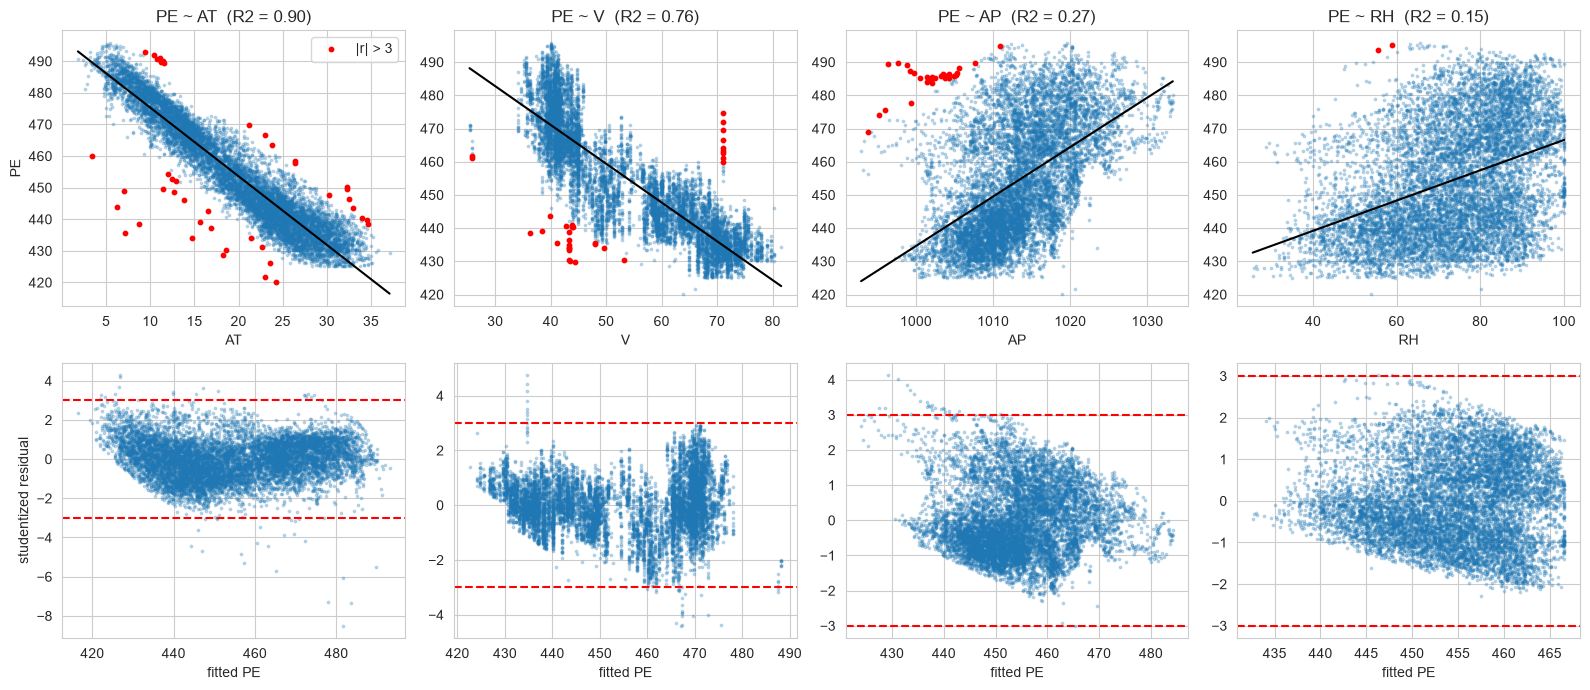

In [8]:
# top row = scatter + fitted line, bottom row = residual plot (one column per predictor)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, x in enumerate(feats):
    m, r = fits[x]
    # True/False mask for the outlier points
    out = abs(r) > 3
    top, bot = axes[0, i], axes[1, i]

    top.scatter(df[x], df.PE, s=3, alpha=0.25)
    top.scatter(df[x][out], df.PE[out], s=10, c='red', label='|r| > 3')
    # draw the regression line: b0 + b1 * x
    xs = np.linspace(df[x].min(), df[x].max(), 100)
    top.plot(xs, m.params['Intercept'] + m.params[x] * xs, 'k')
    top.set(title=f'PE ~ {x}  (R2 = {m.rsquared:.2f})', xlabel=x)

    bot.scatter(m.fittedvalues, r, s=3, alpha=0.25)
    bot.axhline(3, c='red', ls='--')
    bot.axhline(-3, c='red', ls='--')
    bot.set_xlabel('fitted PE')

axes[0, 0].set_ylabel('PE')
axes[0, 0].legend()
axes[1, 0].set_ylabel('studentized residual')
plt.tight_layout()
plt.savefig('figures/simple_regressions.png', dpi=110)
plt.show()

All 4 predictors are significant, p-values are basically 0 for all of them (not surprising with this many rows).
But how much they explain is very different:

- AT alone explains about 90% of the variance in PE, V about 76%
- AP (27%) and RH (15%) are pretty weak on their own

In the residual plots AT and V have a slight curve, the straight line misses a bit at the ends. So there might be some
nonlinearity, which is checked in (f).

Outliers: there are a few dozen with |r| > 3 for AT, V and AP, and only 2 for RH. If the errors were normal we'd expect around 26
(0.27% of 9568), so 42 for AT means the residuals have somewhat heavy tails. It's still less than 0.5% of the data and none
of them look like bad data, so I kept them.

## (d) Multiple regression with all predictors

In [9]:
full = smf.ols('PE ~ AT + V + AP + RH', data=df).fit()
print(full.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:46:40   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

All 4 coefficients have p < 0.001 so we can reject H0: beta_j = 0 for every predictor. R² goes up to 0.93,
slightly better than AT alone (0.90).

RH changed sign here. In (c) the slope was positive, now it's negative. RH is negatively correlated with AT,
so in the simple regression RH was partly picking up the effect of lower temperature. Once AT is in the model,
the actual effect of humidity comes out negative.

## (e) Univariate vs multiple regression coefficients

In [10]:
coefs = pd.DataFrame({
    'uni': [fits[x][0].params[x] for x in feats],
    'multi': full.params[feats].values,
}, index=feats)
coefs

,uni,multi
AT,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


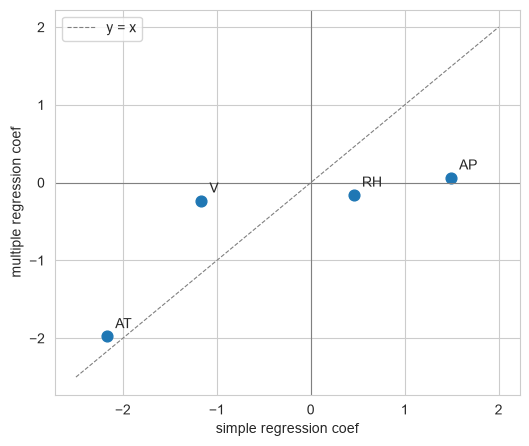

In [11]:
plt.figure(figsize=(6, 5))
plt.scatter(coefs.uni, coefs.multi, s=60)
for x in feats:
    plt.annotate(x, (coefs.uni[x], coefs.multi[x]), xytext=(6, 6), textcoords='offset points')

plt.plot([-2.5, 2], [-2.5, 2], '--', c='grey', lw=0.8, label='y = x')
plt.axhline(0, c='grey', lw=0.8)
plt.axvline(0, c='grey', lw=0.8)
plt.xlabel('simple regression coef')
plt.ylabel('multiple regression coef')
plt.legend()
plt.savefig('figures/coef_comparison.png', dpi=110)
plt.show()

AT barely changes, so its effect is mostly its own. V goes from about -1.17 down to -0.23 because a lot of what V
seemed to explain was really temperature (they're correlated at 0.84). AP drops close to 0 for the same reason,
and RH flips sign like I mentioned in (d).

## (f) Nonlinear association

Fitting PE = b0 + b1 X + b2 X^2 + b3 X^3 for each predictor.

Note: I centered the predictors first. AP is around 1000 so AP^3 is around 10^9, and without centering statsmodels
complains that the matrix is singular. Centering doesn't change the fitted curve or the p-value of the cubic term.

In [12]:
# subtract the mean from each predictor (centering)
# otherwise x, x^2 and x^3 are super correlated and the p-values get weird
dfc = df[feats] - df[feats].mean()
dfc['PE'] = df.PE

rows = []
for x in feats:
    # I(...) tells the formula to actually compute x**2 instead of treating ** as formula syntax
    m = smf.ols(f'PE ~ {x} + I({x}**2) + I({x}**3)', data=dfc).fit()
    # patsy renames I(x**2) to I(x ** 2), hence the spaces
    p = m.pvalues
    rows.append([x, p[x], p[f'I({x} ** 2)'], p[f'I({x} ** 3)'], fits[x][0].rsquared, m.rsquared])

pd.DataFrame(rows, columns=['x', 'p(X)', 'p(X^2)', 'p(X^3)', 'R2 lin', 'R2 cubic']).set_index('x')

,p(X),p(X^2),p(X^3),R2 lin,R2 cubic
x,,,,,
AT,0.0000e+00,3.3118e-231,3.6522e-110,0.8989,0.9119
V,0.0000e+00,8.9770e-131,1.3735e-02,0.7565,0.7750
AP,0.0000e+00,2.1927e-46,2.1233e-67,0.2688,0.2975
RH,9.6487e-152,1.0139e-01,1.4403e-05,0.1519,0.1537


Yes, there is evidence of a nonlinear association for all 4. The cubic term is significant at 5% for every predictor
(V is the weakest one at p = 0.014). For RH the squared term alone is not significant but the cubic term is.

Significant doesn't always mean useful though. AP improves the most (R² from 0.27 to 0.30). RH barely changes
(0.152 to 0.154), with this many rows even a tiny curve becomes significant. AT only gains a little since the
straight line was already good.

## (g) Interactions

In [13]:
# every pair of predictors -> 'AT:V', 'AT:AP', ... (6 pairs total)
# a:b in a formula means the product a*b
inters = [f'{a}:{b}' for a, b in combinations(feats, 2)]
# builds the string 'PE ~ AT + V + AP + RH + AT:V + ...'
m = smf.ols('PE ~ ' + ' + '.join(feats + inters), data=df).fit()

res = pd.DataFrame({'coef': m.params, 'p': m.pvalues})
# True if the term is statistically significant
res['sig'] = res.p < 0.05
res

,coef,p,sig
Intercept,685.7825,3.2316e-18,True
AT,-4.3470,6.7019e-02,False
V,-7.6749,1.3713e-08,True
AP,-0.1524,4.7357e-02,True
RH,1.5709,4.2252e-02,True
AT:V,0.0210,3.3334e-117,True
AT:AP,0.0018,4.5205e-01,False
AT:RH,-0.0052,1.2169e-10,True
V:AP,0.0068,2.8770e-07,True
V:RH,0.0008,8.6194e-02,False


4 out of the 6 interactions are significant at 5%: AT:V, AT:RH, V:AP and AP:RH.
AT:AP (p = 0.45) and V:RH (p = 0.09) are not.

AT itself is only borderline here (p = 0.07) but that's because of the interaction terms that include AT,
it doesn't mean temperature isn't important anymore.

## (h) Improving the model

70/30 train/test split. Comparing:
1. the plain linear model from (d)
2. a model with all linear terms, all squared terms and all pairwise interactions
3. the same model after removing insignificant terms one at a time (backward elimination, remove the highest p-value until all p < 0.05)

In [14]:
# 70% train / 30% test, random_state fixed so results are the same every run
train, test = train_test_split(df, test_size=0.3, random_state=552)

# fits OLS on the given list of terms and returns (model, train MSE, test MSE)
def fit_eval(terms):
    m = smf.ols('PE ~ ' + ' + '.join(terms), data=train).fit()
    return m, mse(train.PE, m.predict(train)), mse(test.PE, m.predict(test))

lin = fit_eval(feats)

# all 2nd order terms = 4 linear + 4 squared + 6 interactions = 14 terms
terms = feats + [f'I({x} ** 2)' for x in feats] + inters
big = fit_eval(terms)

# backward elimination
# keep refitting and throwing out the worst term until everything left is significant
while True:
    # p-values of the current model (we never drop the intercept)
    p = smf.ols('PE ~ ' + ' + '.join(terms), data=train).fit().pvalues.drop('Intercept')
    # stop once even the largest p-value is under 0.05
    if p.max() < 0.05:
        break
    # otherwise remove the term with the biggest p-value and try again
    print(f'dropping {p.idxmax()} (p = {p.max():.3f})')
    terms.remove(p.idxmax())

pruned = fit_eval(terms)
print('kept:', terms)

dropping AT:AP (p = 0.492)
dropping V:RH (p = 0.379)
dropping I(V ** 2) (p = 0.093)
kept: ['AT', 'V', 'AP', 'RH', 'I(AT ** 2)', 'I(AP ** 2)', 'I(RH ** 2)', 'AT:V', 'AT:RH', 'V:AP', 'AP:RH']


In [15]:
pd.DataFrame(
    # len(params) - 1 because we don't count the intercept
    [[len(m.params) - 1, tr, te] for m, tr, te in (lin, big, pruned)],
    index=['linear', 'all 2nd order', '2nd order pruned'],
    columns=['n terms', 'train MSE', 'test MSE'],
)

,n terms,train MSE,test MSE
linear,4,20.3547,21.7414
all 2nd order,14,17.6979,19.0818
2nd order pruned,11,17.7087,19.0829


Adding the squared and interaction terms brings test MSE down from about 21.7 to 19.1 (around 12% better).
Backward elimination removed AT:AP, V:RH and V^2 and the error basically didn't change, so I'd go with the
smaller model. Train and test MSE are close so it's not overfitting.

## (i) KNN regression

Trying k = 1 to 100 on the same train/test split, once with raw features and once with normalized features.
For normalizing I used z-scores (StandardScaler), fit on the training data only.

In [16]:
Xtr, Xte = train[feats].values, test[feats].values
ytr, yte = train.PE.values, test.PE.values

# scaler learns mean/std from the training set only (no peeking at test data)
sc = StandardScaler().fit(Xtr)
# two versions of the features: as-is, and scaled to mean 0 / std 1
data = {'raw': (Xtr, Xte), 'normalized': (sc.transform(Xtr), sc.transform(Xte))}

# try every k from 1 to 100
ks = np.arange(1, 101)
errs = {}
# a = train features, b = test features
for name, (a, b) in data.items():
    tr_err, te_err = [], []
    for k in ks:
        knn = KNeighborsRegressor(k).fit(a, ytr)
        tr_err.append(mse(ytr, knn.predict(a)))
        te_err.append(mse(yte, knn.predict(b)))
    errs[name] = (np.array(tr_err), np.array(te_err))

# best k = the one with the lowest test error (argmin gives the index, ks[...] turns it into k)
best = {name: ks[te.argmin()] for name, (_, te) in errs.items()}
for name, (_, te) in errs.items():
    print(f'{name:>10}: best k = {best[name]}, test MSE = {te.min():.3f}')

       raw: best k = 5, test MSE = 17.222
normalized: best k = 6, test MSE = 16.002


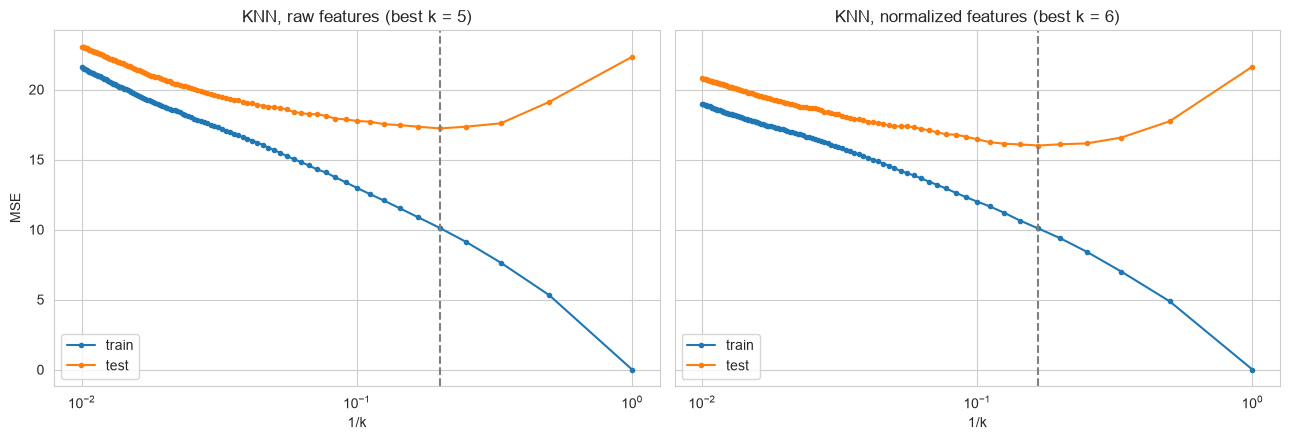

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, (name, (tr, te)) in zip(axes, errs.items()):
    # plot against 1/k so model flexibility goes left -> right (k=1 is the most flexible)
    ax.plot(1 / ks, tr, '.-', label='train')
    ax.plot(1 / ks, te, '.-', label='test')
    ax.axvline(1 / best[name], c='grey', ls='--')
    # linear x-axis crams k=10..100 into the left 10% of the plot
    ax.set_xscale('log')
    ax.set(title=f'KNN, {name} features (best k = {best[name]})', xlabel='1/k')
    ax.legend()

axes[0].set_ylabel('MSE')
plt.tight_layout()
plt.savefig('figures/knn_error_curves.png', dpi=110)
plt.show()

Typical bias-variance tradeoff. On the right side (small k) the model is very flexible, train error goes to 0 at k=1
but test error goes up. On the left (large k) both errors go up since each prediction averages too many neighbors.

Normalizing helps. Without it the distance is dominated by the features with the biggest spread in raw units:
RH spans about 75 and V about 56, while AT (the most important one) only spans 35. So raw KNN doesn't pay enough
attention to temperature. With normalized features the best test MSE goes from 17.2 (k=5) to 16.0 (k=6).

## (j) Comparing KNN and linear regression

In [18]:
cmp = pd.Series({
    'linear': lin[2],
    '2nd order pruned': pruned[2],
    f'KNN raw (k={best["raw"]})': errs['raw'][1].min(),
    f'KNN normalized (k={best["normalized"]})': errs['normalized'][1].min(),
}, name='test MSE').to_frame()
# % change vs plain linear regression (negative = better than linear)
cmp['vs linear (%)'] = (cmp['test MSE'] / lin[2] - 1) * 100
cmp.round(2)

,test MSE,vs linear (%)
linear,21.74,0.00
2nd order pruned,19.08,-12.23
KNN raw (k=5),17.22,-20.78
KNN normalized (k=6),16.00,-26.40


KNN with normalized features has the lowest test error. It's about 26% lower than the plain linear model and about
16% lower than the best regression model from (h). So there is some local structure in the data that a global
2nd order polynomial can't fully capture.

But the regression model still has its advantages. It's much easier to interpret (you can directly read how many MW
you lose per degree of temperature), it's fast, and it behaves reasonably outside the training range. KNN needs to keep
the whole training set and can't really extrapolate. If we just care about prediction accuracy KNN is better, if we
want to understand the plant I'd go with the regression model.

## Extra: 5x2 CV test using all 5 sheets

The dataset readme says the data is given shuffled 5 times so that a 5x2 CV test can be done. So I compared the plain
linear model with normalized KNN (k=6 from part i).

For each sheet: split into two halves, train on one half and test on the other, then swap. That gives 10 differences in MSE.
Then the 5x2cv paired t-test (Dietterich 1998):

$$t = \frac{p_1^{(1)}}{\sqrt{\frac{1}{5}\sum_{i=1}^{5} s_i^2}}, \quad s_i^2 = (p_i^{(1)} - \bar p_i)^2 + (p_i^{(2)} - \bar p_i)^2$$

where p_i^(j) is the MSE difference on fold j of shuffle i. Under H0 this follows a t distribution with 5 degrees of freedom.

In [19]:
# read all 5 sheets at once -> gives a dict like {'Sheet1': df1, 'Sheet2': df2, ...}
sheets = pd.read_excel('Folds5x2_pp.xlsx', sheet_name=None)

# trains both models on tr and returns their test MSE on te
def both_mse(tr, te):
    # linear regression (add_constant adds the intercept column)
    ols = sm.OLS(tr.PE, sm.add_constant(tr[feats])).fit()
    lin_mse = mse(te.PE, ols.predict(sm.add_constant(te[feats])))

    # KNN with k=6 on standardized features
    # scaler is fit on the training half only, then used on both halves
    sc = StandardScaler().fit(tr[feats])
    knn = KNeighborsRegressor(n_neighbors=6).fit(sc.transform(tr[feats]), tr.PE)
    knn_mse = mse(te.PE, knn.predict(sc.transform(te[feats])))

    return lin_mse, knn_mse

rows = []
for name, d in sheets.items():
    # split the sheet into two halves
    half = len(d) // 2
    a = d.iloc[:half]
    b = d.iloc[half:]

    # fold 1: train on first half, test on second half
    lin1, knn1 = both_mse(a, b)
    rows.append([name, 1, lin1, knn1])

    # fold 2: swap them
    lin2, knn2 = both_mse(b, a)
    rows.append([name, 2, lin2, knn2])

# 10 rows total (5 sheets x 2 folds)
cv = pd.DataFrame(rows, columns=['sheet', 'fold', 'linear MSE', 'KNN MSE'])
# positive diff means KNN did better on that fold
cv['diff'] = cv['linear MSE'] - cv['KNN MSE']
cv

,sheet,fold,linear MSE,KNN MSE,diff
0,Sheet1,1,21.0123,16.0774,4.9349
1,Sheet1,2,20.6081,15.6800,4.9281
2,Sheet2,1,20.9802,15.8734,5.1068
3,Sheet2,2,20.6908,16.1719,4.5189
4,Sheet3,1,20.8841,15.8126,5.0715
5,Sheet3,2,20.7009,16.0581,4.6428
6,Sheet4,1,19.8597,15.8620,3.9977
7,Sheet4,2,21.7415,16.2728,5.4687
8,Sheet5,1,20.4679,15.8821,4.5858
9,Sheet5,2,21.1573,16.6901,4.4672


In [20]:
# 5x2 cv paired t-test (Dietterich)
# reshape the 10 diffs into 5 rows (sheets) x 2 cols (folds)
d = cv['diff'].values.reshape(5, 2)
# variance of the 2 diffs within each sheet (one number per sheet)
s2 = ((d - d.mean(axis=1, keepdims=True)) ** 2).sum(axis=1)
# test statistic = very first diff / sqrt(average variance)
t = d[0, 0] / np.sqrt(s2.mean())
# two-sided p-value from a t distribution with 5 degrees of freedom
p = 2 * stats.t.sf(abs(t), df=5)

print(cv[['linear MSE', 'KNN MSE']].mean().round(3).to_string())
print(f't = {t:.3f}, p = {p:.4f}')

linear MSE    20.810
KNN MSE       16.038
t = 9.484, p = 0.0002


KNN is better than linear regression in all 10 folds, by about 4.8 on average. The test gives t = 9.5 with 5 degrees of
freedom (p = 0.0002), so the difference is significant and not just because of the one 70/30 split I used earlier.